In [79]:
from narwhals.selectors import categorical
!pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\HP\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,KFold,learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from scipy.stats import entropy
import os
from tqdm import tqdm

%matplotlib inline
plt.style.use(r"E:\BongoDev\Regression Analysis\deeplearning.mplstyle")

In [81]:
"""
Machine Learning Algorithm:
1. Supervised learning: data contains labels i.e Regression,Classification
2. Unsupervised Learning: data does not contain lables i.e. Clustering
3. Reinforcement Learning : Machine learns through penalty/reward/feedback systems
    i.e. ChatGPT
    1. Train a Text to Text generation model
    2. Task Specific fine tuning the model using reinforcement learning
"""

ROOT_DIR="E:\\BongoDev\\Regression Analysis"
DATA_DIR=os.path.join(ROOT_DIR,"Data")
Dataset_path=os.path.join(DATA_DIR,'housing.csv')



In [82]:
housing_dataset=pd.read_csv(Dataset_path)
housing_dataset.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [83]:
housing_dataset.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [84]:
housing_dataset=housing_dataset[['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus','price']]


In [85]:
housing_dataset.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,13300000
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,12250000
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,12250000
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,12215000
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,11410000


In [86]:
housing_dataset.isnull().sum()

area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
price               0
dtype: int64

In [87]:
housing_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   area              545 non-null    int64
 1   bedrooms          545 non-null    int64
 2   bathrooms         545 non-null    int64
 3   stories           545 non-null    int64
 4   mainroad          545 non-null    str  
 5   guestroom         545 non-null    str  
 6   basement          545 non-null    str  
 7   hotwaterheating   545 non-null    str  
 8   airconditioning   545 non-null    str  
 9   parking           545 non-null    int64
 10  prefarea          545 non-null    str  
 11  furnishingstatus  545 non-null    str  
 12  price             545 non-null    int64
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [88]:
"""
Normalization:
1. Min-Max Normalization   ( 0 -1)
       xmin=20
       xmax=40
       range=20
       if x=30 then x_norm=(x-xmin)/range  =  (30-20)/20=0.5

2. Standardization/ Z-score  (Mean=0, Std=1,Zero Mean,Unit Variance)  ( DEFAULT)
       mean=20
       std=30
       if =30 then z-score=(x-mean)/std=(30-20)/30=0.33

       for example we have 10 images each 3 X 3
       average image=[_ _ _
                      _ _ _
                      _ _ _
                     ]
       For a single image:
              1. remove average image from that image
              2. normalize by diving the std
"""
# Select columns

numerical_cols=housing_dataset.select_dtypes(include='number').columns.drop('price')
categorical_cols=housing_dataset.select_dtypes(include=['object','str']).columns
numerical_cols

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='str')

In [89]:
categorical_cols

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [90]:
scaler=StandardScaler()

housing_dataset[numerical_cols]=scaler.fit_transform(housing_dataset[numerical_cols])

In [91]:
housing_dataset.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price
0,1.046726,1.403419,1.421812,1.378217,yes,no,no,no,yes,1.517692,yes,furnished,13300000
1,1.757010,1.403419,5.405809,2.532024,yes,no,no,no,yes,2.679409,no,furnished,12250000
2,2.218232,0.047278,1.421812,0.224410,yes,no,yes,no,no,1.517692,yes,semi-furnished,12250000
3,1.083624,1.403419,1.421812,0.224410,yes,no,yes,no,yes,2.679409,yes,furnished,12215000
4,1.046726,1.403419,-0.570187,0.224410,yes,yes,yes,no,yes,1.517692,no,furnished,11410000


In [92]:
"""
Categorical cols
1.One-hot encoding
2.Label Encoding
3.Ordinal Encoding ( for data in order)

"""
categorical_cols

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [93]:
le=LabelEncoder()
for col in categorical_cols:
    housing_dataset[col]=le.fit_transform(housing_dataset[col])

housing_dataset.head()


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price
0,1.046726,1.403419,1.421812,1.378217,1,0,0,0,1,1.517692,1,0,13300000
1,1.757010,1.403419,5.405809,2.532024,1,0,0,0,1,2.679409,0,0,12250000
2,2.218232,0.047278,1.421812,0.224410,1,0,1,0,0,1.517692,1,1,12250000
3,1.083624,1.403419,1.421812,0.224410,1,0,1,0,1,2.679409,1,0,12215000
4,1.046726,1.403419,-0.570187,0.224410,1,1,1,0,1,1.517692,0,0,11410000


In [94]:
housing_dataset['guestroom'].value_counts()

guestroom
0    448
1     97
Name: count, dtype: int64

In [95]:
"""
Population ->sample -->resample(train-test-val)
"""
X=housing_dataset.drop('price',axis=1).values
y=housing_dataset['price'].values
print(X.shape)
print(y.shape)

(545, 12)
(545,)


In [96]:
X_train_val,X_test,y_train_val,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)
X_train_val.shape,y_train_val.shape,X_test.shape,y_test.shape

((436, 12), (436,), (109, 12), (109,))

In [97]:
X_train,X_val,y_train,y_val=train_test_split(
    X_train_val,y_train_val,test_size=0.25,random_state=42
)

In [98]:
print(f"TrainSIZE:{len(X_train)},ValSize:{len(X_val)},TestSize:{len(X_test)}")

TrainSIZE:327,ValSize:109,TestSize:109


In [99]:
"""
Multiple Value Linear Regression Model
y_pred=w*x+b

x=[x1 ,x2 ,x3]
w=[w1,w2,w3]

y_pred=x1*w1+x2*w2+x3*w3+b
"""

def model(x,w,b):
    y_pred=np.dot(x,w)+b
    return y_pred

In [100]:
def cost_function(x,y,w,b):
    y_pred=model(x,w,b)
    mse=np.mean((y-y_pred)**2)
    return mse

In [101]:
def compute_gradients(x,y_true,w,b):
    delta=1e-9
    cost_1=cost_function(x,y_true,w,b)
    cost_2=cost_function(x,y_true,w+delta,b)
    cost_3=cost_function(x,y_true,w,b+delta)
    dw=(cost_2-cost_1)/delta
    db=(cost_3-cost_1)/delta
    return dw,db

In [102]:
# Initialize paramters
np.random.seed(42)
w_init=np.random.randn(X_train.shape[1])*0.01
b_init=0.0

w_init


array([ 0.00496714, -0.00138264,  0.00647689,  0.0152303 , -0.00234153,
       -0.00234137,  0.01579213,  0.00767435, -0.00469474,  0.0054256 ,
       -0.00463418, -0.0046573 ])

In [103]:
# Hyperparameters
learning_rate=0.01
epochs=50000

In [104]:
# Gradient Descent
# In each epoch 1. Loss calculate 2. Gradient Calculate 3.Weight Update
#Train Model

def fit(X_train,y_train,w_init,b_init,learning_rate,epochs,X_val=None,y_val=None):
    w=w_init.copy()
    b=b_init
    train_losses,val_losses=[],[]

    for i in tqdm(range(epochs)):
        dw,db=compute_gradients(X_train,y_train,w,b)
        w=w-dw*learning_rate
        b=b-db*learning_rate

        if i%100==0:
            train_loss=cost_function(X_train,y_train,w,b)
            train_losses.append(train_loss)
            if X_val is not None and y_val is not None:
                val_loss=cost_function(X_val,y_val,w,b)
                val_losses.append(val_loss)
            else:
                val_losses.append(None)
    return w,b,train_losses,val_losses


In [105]:
w_final,b_final,train_losses,val_losses=fit(X_train, y_train, w_init, b_init, learning_rate, epochs, X_val, y_val)

100%|██████████| 50000/50000 [00:01<00:00, 30348.05it/s]


In [106]:
print("Training Completed")
print(f"Final Training Loss:{train_losses[-1]//1e9:.4f}")
print(f"Final Validation Loss:{val_losses[-1]//1e9:.4f}")

Training Completed
Final Training Loss:1412.0000
Final Validation Loss:1465.0000


In [107]:
"""
SPLITTING METHOD:
1. Train-Test-Validation Split : Split the data into 3 partitions (when the size of the dataset is very large)
2. K-fold Cross Validation : Partition dataset into k folds and use 1 fold for testing   (when dataset is small)
    dataset ={1,2,3,4,5,6,7,8,9,10}
    k=5
    fold1={1,2}
    fold2={3,4}
    fold3={5,6}
    fold4={7,8}
    fold5={9,10}

    Iteration | Training Data | Testing Data | Acc
    1         | fold 1,2,3,4  | fold 5       | 80
    2         | fold 1,2,3,5  | fold 4       | 75
    3         | fold 1,2,4,5  | fold 3       |
    4         | fold 1,3,4,5  | fold 2       |
    5         | fold 2,3,4,5  | fold 1       | 78

average=(80+75+.....+78) /5
std=

Ans: average +- std
"""

# Cross validation

kf=KFold(n_splits=5,shuffle=True,random_state=42)
cv_mse_scores=[]

print("Performing 5 fold Cross validation")
for fold,(train_idx,val_indx) in enumerate(kf.split(X_train_val)):
    X_fold_train,X_fold_val=X_train_val[train_idx],X_train_val[val_indx]
    y_fold_train,y_fold_val=y_train_val[train_idx],y_train_val[val_indx]

    # Reinitialize model
    w_fold=np.random.randn(X_fold_train.shape[1])*0.01
    b_fold=0.0

    #Train
    w_fold,b_fold,_,_=fit(
        X_fold_train,y_fold_train,w_fold,b_fold,learning_rate,epochs,
    )
    # Evaluate
    y_pred_val=X_fold_val @ w_fold +b_fold
    mse=mean_squared_error(y_fold_val,y_pred_val)
    cv_mse_scores.append(mse)
    print(f"Fold {fold+1} MSE: {mse:.4f}")

print(f"Cross-Validation MSE:{np.mean(cv_mse_scores):.4f} ± {np.std(cv_mse_scores):.4f}")


Performing 5 fold Cross validation


100%|██████████| 50000/50000 [00:01<00:00, 29678.51it/s]


Fold 1 MSE: 1629306615921.8201


100%|██████████| 50000/50000 [00:01<00:00, 28004.69it/s]


Fold 2 MSE: 1105581133850.1968


...

Fold 3 MSE: 1361781518208.3955


100%|██████████| 50000/50000 [00:01<00:00, 27112.47it/s]


Fold 4 MSE: 1729602423853.3643


100%|██████████| 50000/50000 [00:01<00:00, 29179.97it/s]

Fold 5 MSE: 1244964920843.9321
Cross-Validation MSE:1414247322535.5417 ± 233402376929.9235


In [108]:
# KL DIVERGENCE

def kl_divergence(y_true,y_pred,bins=50):
    hist_true,_=np.histogram(y_true,bins=bins,density=True)
    hist_pred,_=np.histogram(y_pred,bins=bins,density=True)
    return entropy(hist_true+1e-10,hist_pred+1e-10)

y_train_pred=model(X_train,w_final,b_final)
y_val_pred=model(X_val,w_final,b_final)
y_test_pred=model(X_test,w_final,b_final)

kl_train=kl_divergence(y_train,y_train_pred)
kl_val=kl_divergence(y_val,y_val_pred)
kl_test=kl_divergence(y_test,y_test_pred)

In [109]:
print(f"KL Divergence → Train: {kl_train:.4f}, Val: {kl_val:.4f}, Test: {kl_test:.4f}")

KL Divergence → Train: 0.4821, Val: 1.0458, Test: 0.7085


In [110]:
# Manual Learning Curve

def plot_learning_curve(X,y,X_val,y_val):
    train_errors,val_errors=[],[]
    m=len(X)
    sizes=np.linspace(100,m,10).astype(int)

    for size in sizes:
        error_train,error_val=[],[]
        for _ in range(3):   #Average over 3 runs
            idx=np.random.choice(m,size,replace=False)
            X_sub,y_sub=X[idx],y[idx]

            w_sub=np.random.randn(X_sub.shape[1])*0.01
            b_sub=0.0
            w_sub,b_sub,_,_=fit(X_sub,y_sub,w_sub,b_sub,0.01,3000)

            train_err=cost_function(X_sub,y_sub,w_sub,b_sub)
            val_err=cost_function(X_val,y_val,w_sub,b_sub)
            error_train.append(train_err)
            error_val.append(val_err)
        train_errors.append(np.mean(error_train))
        val_errors.append(np.mean(error_val))
    plt.figure()
    plt.plot(sizes,train_errors,'o-',label='Training error')
    plt.plot(sizes,val_errors,'o-',label='Validation error')
    plt.title("learning Curve:Bias-Variance Diagnosis")
    plt.xlabel('Training Size set')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)
    plt.show()



100%|██████████| 3000/3000 [00:00<00:00, 21730.23it/s]


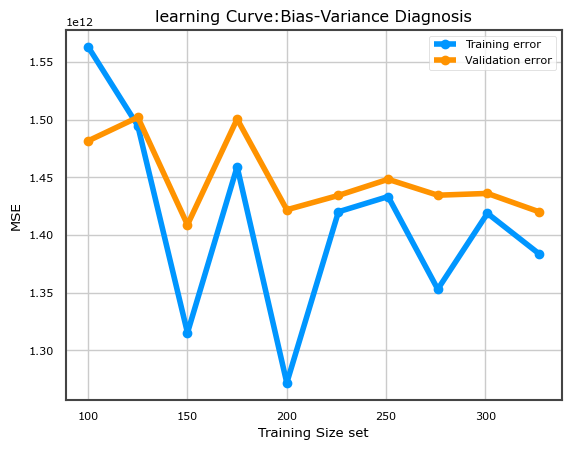

In [111]:
"""
THEORETICAL CONCEPT: Learning Curves (Bias-Variance Diagnosis)
- Plot train/validation error vs. training size
- High bias: both errors high and close
- High variance: train error low, val error high (gap)
"""
plot_learning_curve(X_train,y_train,X_val,y_val)

100%|██████████| 3000/3000 [00:00<00:00, 33909.35it/s]


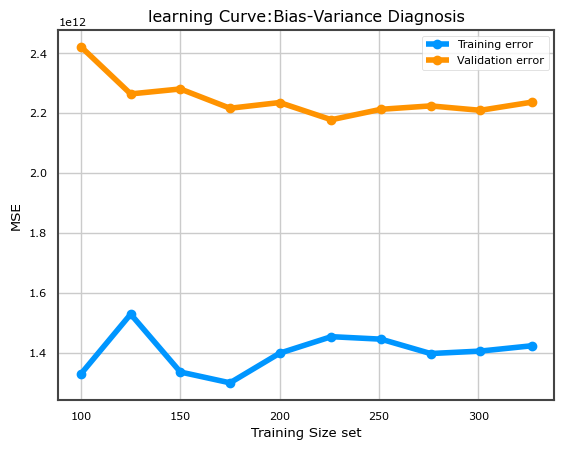

In [114]:
plot_learning_curve(X_train,y_train,X_test,y_test)


In [115]:
"""
Learning ability of models:
1. Overfitting (high variance): loss is very low in training data , very high in testing
2. Underfitting (high bias): loss is very high in training data, very high in testing data
3. Generalization: Low loss in training data, ,low loss in testing **


THEORETICAL CONCEPT: Bias-Variance Tradeoff Summary

Bias: The error due to overly simplistic assumptions in the model, causing consistent underfitting.
Variance: The error due to excessive sensitivity to small fluctuations in the training data, causing overfitting.

Underfitting: Model performs poor in training set, but poorly on test set
Overfitting: Model performs really good in training set, but poorly on test set

Total Error = Bias² + Variance + Irreducible Error

| Case              | Train Error | Val Error | Gap? | Diagnosis         |
|-------------------|-------------|-----------|------|-------------------|
| High Bias         | High        | High      | Small| Underfitting      |
| High Variance     | Low         | High      | Large| Overfitting       |
| Good Fit          | Low         | Low       | Small| Generalization    |

Actions:
- High Bias → Increase model complexity, add features
- High Variance → More data, regularization, reduce features
"""

print("""
BIAS-VARIANCE DIAGNOSTIC SUMMARY:
- If training and validation errors are both high → High Bias (add features/polynomial terms)
- If training error low, validation high → High Variance (regularize, more data)
- Use cross-validation and learning curves to confirm.
""");



BIAS-VARIANCE DIAGNOSTIC SUMMARY:
- If training and validation errors are both high → High Bias (add features/polynomial terms)
- If training error low, validation high → High Variance (regularize, more data)
- Use cross-validation and learning curves to confirm.

